In [1]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

Question 1

Line parameters (a, b, c): 0.18896104236887284 -0.15926349508910098 -0.96898341760779


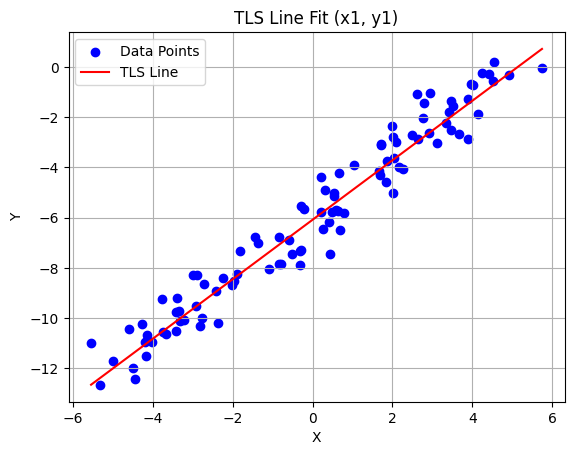

In [57]:
D = np.genfromtxt("csv/lines.csv", delimiter=",", skip_header=1)

x1 = D[:, 0]
y1 = D[:, 3]

# Build A matrix
A = np.column_stack((x1, y1, np.ones_like(x1)))

# SVD
U, S, Vt = np.linalg.svd(A)

# TLS solution is equivalent to the smallest singular vector of A
a, b, c = Vt[-1]

print("Line parameters (a, b, c):", a, b, c)

# ----------------------------------------
# Convert ax + by + c = 0 → y = mx + b
# ----------------------------------------
m = -a / b
intercept = -c / b

# Create x values for plotting line
x_vals = np.linspace(min(x1), max(x1), 100)
y_vals = m * x_vals + intercept

# ----------------------------------------
# Plot
# ----------------------------------------
plt.scatter(x1, y1, color='blue', label='Data Points')
plt.plot(x_vals, y_vals, color='red', label='TLS Line')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("TLS Line Fit (x1, y1)")
plt.legend()
plt.grid(True)
plt.show()

26 inliers found for line 1
23 inliers found for line 2
23 inliers found for line 3
Line 1: a=1.1803473205370607, b=2.77154244355646, c=-6.059703791099263
Line 2: a=2.2946755197954474, b=-2.3485649836860993, c=1.7745945973373367
Line 3: a=-4.168535444036682, b=2.750019827148103, c=18.45537203138827


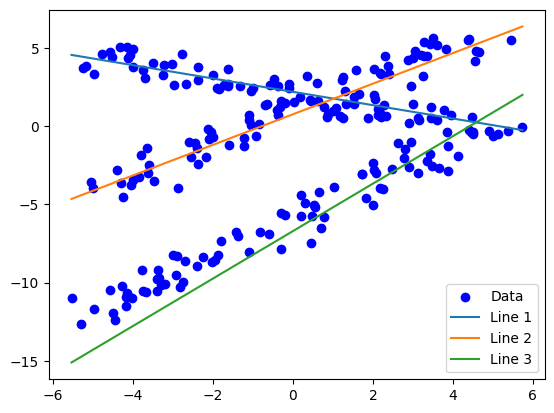

In [59]:
# Fix random seed so results are reproducible
np.random.seed(42)

# ---------------------------------------------
# Function to compute line parameters from 2 points
# Line is represented as: ax + by + c = 0
# ---------------------------------------------
def fit_line(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    
    a = y1 - y2
    b = x2 - x1
    c = x1*y2 - x2*y1
    
    return a, b, c

# ---------------------------------------------
# Function to compute perpendicular distance
# from points (x, y) to line ax + by + c = 0
# ---------------------------------------------
def distance(a, b, c, x, y):
    return np.abs(a*x + b*y + c) / np.sqrt(a*a + b*b)

# ---------------------------------------------
# RANSAC algorithm to find best line
# ---------------------------------------------
def ransac_line(X, Y, threshold=0.1, iterations=1000):
    best_inliers = []
    best_model = None
    
    n = len(X)
    
    for _ in range(iterations):
        # Step 1: randomly pick 2 points
        idx = np.random.choice(n, 2, replace=False)
        p1 = (X[idx[0]], Y[idx[0]])
        p2 = (X[idx[1]], Y[idx[1]])
        
        # Step 2: fit line through these 2 points
        a, b, c = fit_line(p1, p2)
        
        # Step 3: compute distance of ALL points to this line
        d = distance(a, b, c, X, Y)

        # Step 4: find inliers (consensus set)
        inliers = np.where(d < threshold)[0]
        
        # Step 5: keep the model with maximum inliers
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a, b, c)
    
    return best_model, best_inliers

X_all = D[:, :3].flatten()
Y_all = D[:, 3:].flatten()

lines = []

# Loop to find 3 lines
for i in range(3):
    model, inliers = ransac_line(X_all, Y_all)
    lines.append(model)
    
    # mask the consensus set (inliers)
    mask = np.ones(len(X_all), dtype=bool)
    mask[inliers] = False
    
    X_all = X_all[mask]
    Y_all = Y_all[mask]

    print(len(inliers), "inliers found for line", i+1)

for i, (a, b, c) in enumerate(lines):
    print(f"Line {i+1}: a={float(a)}, b={float(b)}, c={float(c)}")

plt.scatter(X_all, Y_all, color='blue', label='Data')

x_vals = np.linspace(min(X_all), max(X_all), 100)

for i, (a, b, c) in enumerate(lines):
    m = -a / b
    intercept = -c / b
    
    plt.plot(x_vals, m * x_vals + intercept,
             label=f'Line {i+1}')

plt.legend()
plt.show()

Question 2

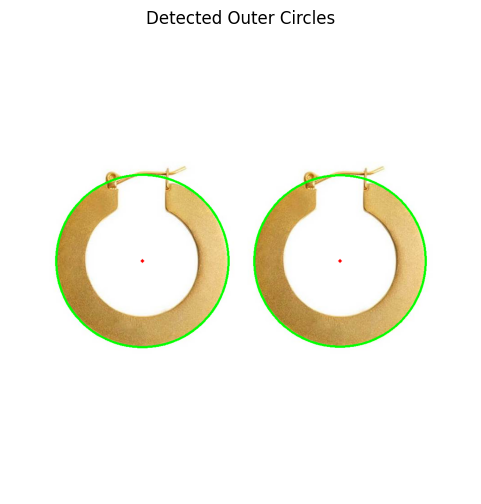

In [76]:
import cv2
import numpy as np

# Load image
img = cv2.imread('images/earrings.jpg')
output = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur to reduce noise
gray = cv2.GaussianBlur(gray, (9, 9), 2)

# Detect circles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,              # resolution ratio
    minDist=100,         # distance between circles (important for 2 earrings)
    param1=100,          # Canny edge upper threshold
    param2=30,           # circle detection threshold (lower = more circles)
    minRadius=100,        # filter small circles
    maxRadius=200        # adjust based on image
)

# Draw detected circles
if circles is not None:
    circles = np.uint16(np.around(circles))
    for (x, y, r) in circles[0, :]:
        # outer circle
        cv2.circle(output, (x, y), r, (0, 255, 0), 3)
        # center
        cv2.circle(output, (x, y), 2, (0, 0, 255), 3)

# pick the largest circle per earring
circles = sorted(circles[0], key=lambda c: c[2], reverse=True)

# take biggest ones (2 earrings → 2 biggest circles)
selected = circles[:2]

# Convert BGR → RGB
output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(output_rgb)
ax.set_title("Detected Outer Circles")
ax.axis('off')

plt.show()

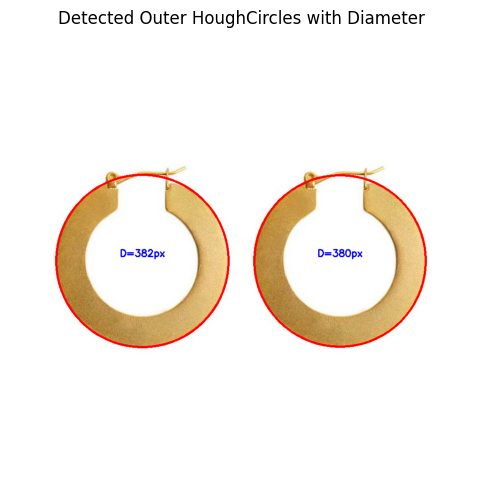

Earring 1: 7.52 cm
Earring 2: 7.56 cm


In [99]:
img = cv2.imread('images/earrings.jpg')
output = img.copy()

# Convert to grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Blur to reduce noise
gray = cv2.GaussianBlur(gray, (9, 9), 2)

# Detect circles
circles = cv2.HoughCircles(
    gray,
    cv2.HOUGH_GRADIENT,
    dp=1.2,
    minDist=100,
    param1=100,
    param2=30,
    minRadius=100,
    maxRadius=200
)

if circles is not None:
    circles = np.uint16(np.around(circles[0]))

    selected = circles

    # Draw + print diameter
    for i, (x, y, r) in enumerate(selected, 1):
        diameter = 2 * r

        # Draw circle
        cv2.circle(output, (x, y), r, (0, 0, 255), 3)

        # Draw diameter text
        cv2.putText(output,
                    f"D={diameter}px",
                    (x - 50, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.7,
                    (255, 0, 0),
                    2)

output_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
ax.imshow(output_rgb)
ax.set_title("Detected Outer HoughCircles with Diameter")
ax.axis('off')

plt.show()

FOCAL_LENGTH_MM = 8
DISTANCE_MM = 720
PIXEL_SIZE_MM = 0.0022  # 2.2 micrometers

# Magnification
m = FOCAL_LENGTH_MM / DISTANCE_MM

# Conversion factor
scale_factor = PIXEL_SIZE_MM / m

for i, (x, y, r) in enumerate(selected, 1):
    diameter_px = 2 * r
    diameter_mm = diameter_px * scale_factor

    print(f"Earring {i}: {diameter_mm/10:.2f} cm")
